# Notebook Dedicated to Study the Event Candidates on 2.2PPO Phase (initially above 5 MeV)

In [1]:
import numpy as np

import glob
import pickle

import seaborn as sn
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, ScalarFormatter
from matplotlib.font_manager import FontProperties
from matplotlib import font_manager
from matplotlib import cm

# Load and Cut Data

In [11]:
# ------- Observable list -------
obs_list = ['energy_corrected', 'posr_av', 'posx', 'posy', 'posz_av', 'runID', 'itr', 'eventID']

# ------- Observable Dictionary -------
obs_dict = {obs: np.array([]) for obs in obs_list}

# ------- Directory of data -------
candidates_data_dir = 'E:/Data/solars/solarnu_Realdata/2p2PPO/resume_files/'
hs_dir = 'E:/Data/solars/solarnu_Realdata/2p2PPO/HS_results/pkl_resume/'

# Loop over the observable list to load the candidates data in obs_dict
for obs in obs_list:
    
    obs_dir = candidates_data_dir + obs + '.npy'
    obs_i = np.load(obs_dir)
    obs_dict[obs] = np.append(obs_dict[obs], obs_i)

print(f'Nº of intial events : {len(obs_dict['energy_corrected'])}')

# ===== Apply General Cuts =====
en_inf_cut = 5
posr_cut = 5500

energy_condition = (obs_dict['energy_corrected'] >= en_inf_cut)
posr_condition = (obs_dict['posr_av'] <= posr_cut)
runID_condition = (obs_dict['runID'] > 301000)
itr_condition = (obs_dict['itr'] >= 0.20)

mask = (energy_condition & posr_condition & runID_condition & itr_condition)

energy = obs_dict['energy_corrected'][mask]
posr_av = obs_dict['posr_av'][mask]
posx = obs_dict['posx'][mask]
posy = obs_dict['posy'][mask]
posz = obs_dict['posz_av'][mask]
runID = obs_dict['runID'][mask]
itr = obs_dict['itr'][mask]
eventID = obs_dict['eventID'][mask]

print(f'Nº of events after basic cuts: {len(energy)}')

# ===== Now Apply Hotspot Cuts =====

# Load HS results
with open(hs_dir + 'hs_prompt_resume.pkl', 'rb') as f:
    hs_prompt_dict = pickle.load(f)
    
    hs_prompt_eventID = hs_prompt_dict['eventID']
    hs_prompt_runID = hs_prompt_dict['runID']
    
with open(hs_dir + 'hs_delay_resume.pkl', 'rb') as f:
    hs_delay_dict = pickle.load(f)
    
    hs_delay_eventID = hs_delay_dict['eventID']
    hs_delay_runID = hs_delay_dict['runID']

hs_eventID = np.concatenate((hs_prompt_eventID, hs_delay_eventID))
hs_runID = np.concatenate((hs_prompt_runID, hs_delay_runID))

# Remove coincident eventID and runID events with tagged HS eventID and runID
# Create an unique number such that runID*offset + eventID is an unique number

offset = np.int64(10**10)

unique_id_data = (runID.astype(np.int64) * offset) + eventID.astype(np.int64)
unique_id_hs = (hs_runID.astype(np.int64) * offset) + hs_eventID.astype(np.int64)

is_hotspot = np.isin(unique_id_data, unique_id_hs)

hs_cut = ~is_hotspot

# Select the data
energy = energy[hs_cut]
posr_av = posr_av[hs_cut]
posx = posx[hs_cut]
posy = posy[hs_cut]
posz = posz[hs_cut]
runID = runID[hs_cut]
itr = itr[hs_cut]
eventID = eventID[hs_cut]

print(f'Nº of events after removing HS events: {len(energy)}')

Nº of intial events : 33543
Nº of events after basic cuts: 174
Nº of events after removing HS events: 173


# Plots

In [3]:
save_path = 'figs/above_5_MeV_solar_results/'

# -------- Font Properties --------

font_style_title = {'family':'serif', 'weight': 'normal','color':'black','size':12}
font_style_axis= {'family':'serif', 'weight': 'normal','color':'black','size':11}

font_prop = font_manager.FontProperties(family=font_style_axis['family'], weight=font_style_axis['weight'], size=9)

## Energy

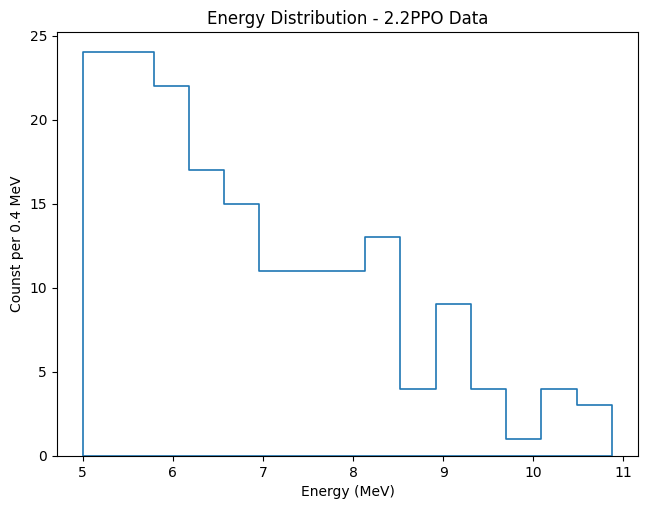

In [4]:
binwidth = 0.4

plt.figure(figsize = (7.5, 5.5))
sn.histplot(energy, binwidth = binwidth, element = 'step', alpha = 0, linewidth = 1.2)

plt.xlabel('Energy (MeV)')
plt.ylabel(f'Counst per {binwidth} MeV')

plt.title('Energy Distribution - 2.2PPO Data')

plt.show()

## pos_r

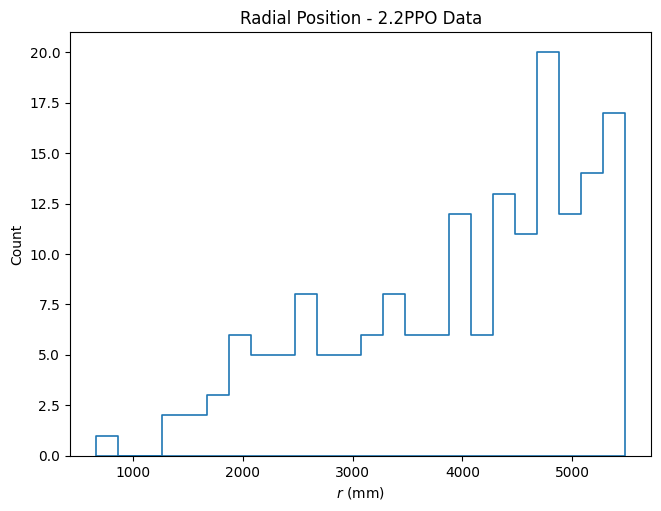

In [5]:
binwidth = 200

plt.figure(figsize = (7.5, 5.5))
sn.histplot(posr_av, binwidth = binwidth, element = 'step', alpha = 0, linewidth = 1.2)

plt.xlabel(r'$r$ (mm)')

plt.title('Radial Position - 2.2PPO Data')

plt.show()

## Norm. Pos_r

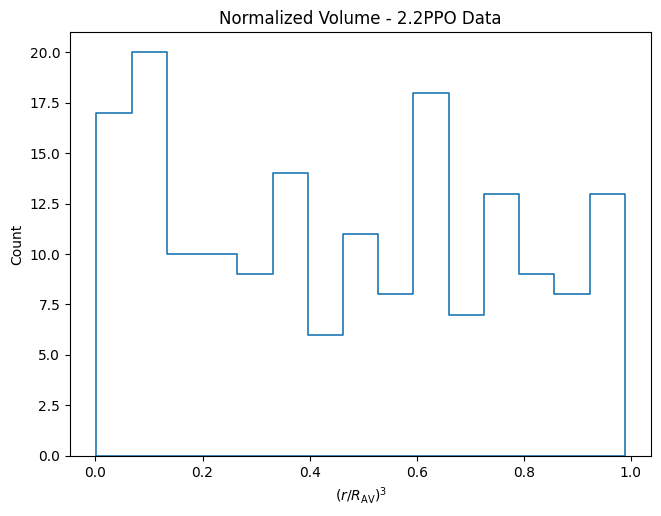

In [6]:
R_cut = 5500
norm_vol = (posr_av**3)/(R_cut**3)

bins = 15

plt.figure(figsize = (7.5, 5.5))
sn.histplot(norm_vol, bins = bins, element = 'step', alpha = 0, linewidth = 1.2)

plt.xlabel(r'$(r/R_\text{AV})^3$')

plt.title('Normalized Volume - 2.2PPO Data')

plt.show()

## rho^2

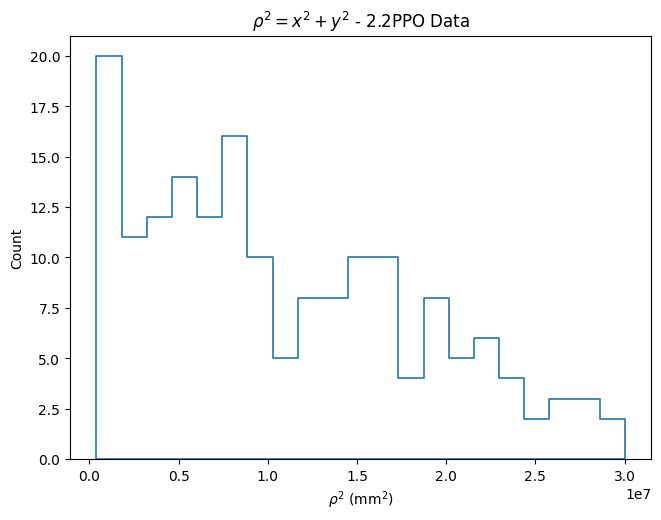

In [7]:
rho_sqr = (posx**2) + (posy**2)

binwidth = 1200**2

plt.figure(figsize = (7.5, 5.5))
sn.histplot(rho_sqr, binwidth = binwidth, element = 'step', alpha = 0, linewidth = 1.2)

plt.xlabel(r'$\rho^2$ (mm$^2$)')

plt.title(r'$\rho^2 = x^2 + y^2$ - 2.2PPO Data')

plt.show()

## x vs. y

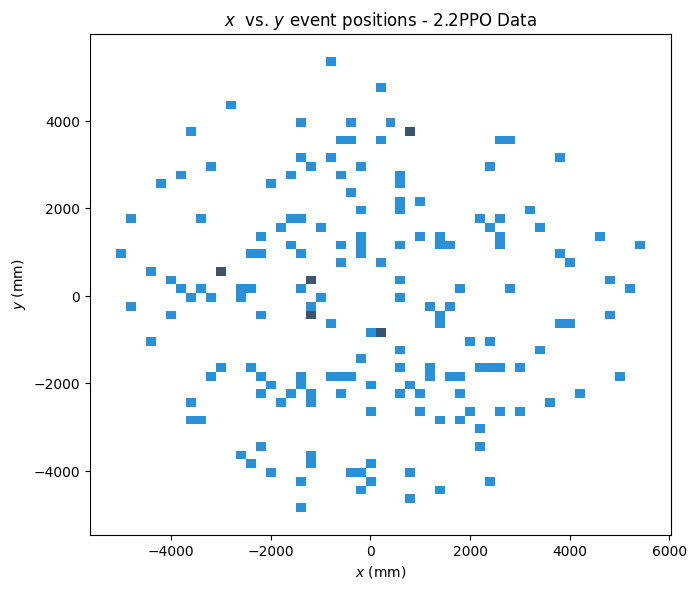

In [8]:
binwidth_x = 200
binwidth_y = 200

plt.figure(figsize = (7.5, 6.5))
sn.histplot(x = posx, y = posy, binwidth = (binwidth_x, binwidth_y))

plt.xlabel(r'$x$ (mm)')
plt.ylabel('$y$ (mm)')

plt.title(r'$x$  vs. $y$ event positions - 2.2PPO Data')

plt.show()

## z vs. rho^2

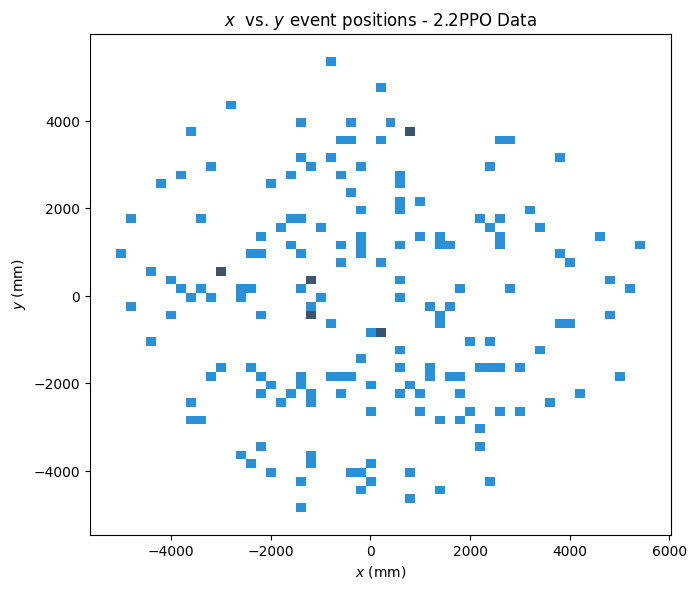

In [9]:
binwidth_x = 200
binwidth_y = 200

plt.figure(figsize = (7.5, 6.5))
sn.histplot(x = posx, y = posy, binwidth = (binwidth_x, binwidth_y))

plt.xlabel(r'$x$ (mm)')
plt.ylabel('$y$ (mm)')

plt.title(r'$x$  vs. $y$ event positions - 2.2PPO Data')

plt.show()

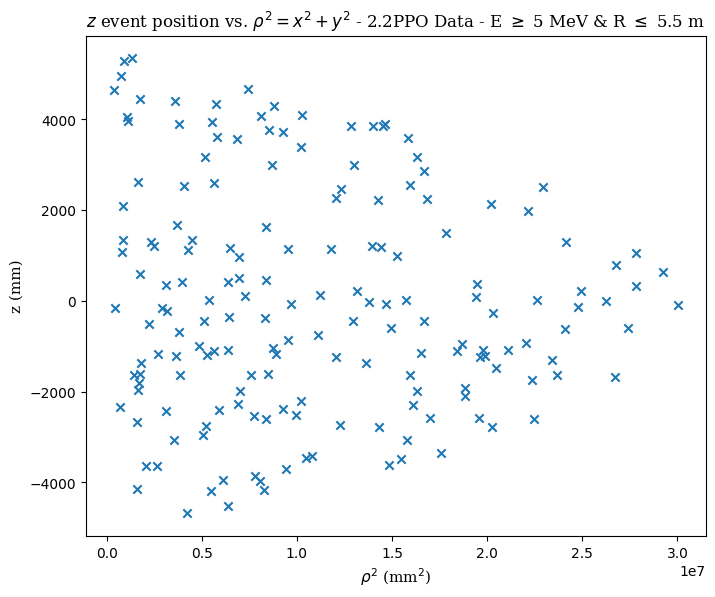

In [19]:
plt.figure(figsize = (8, 6.5))
plt.scatter(x = rho_sqr, y = posz, marker = 'x')

plt.xlabel(r'$\rho^2$ (mm$^2$)', fontdict = font_style_axis)
plt.ylabel('z (mm)', fontdict = font_style_axis)

#plt.xlim(-10,)

plt.title(fr'$z$ event position vs. $\rho^2 = x^2 + y^2$ - 2.2PPO Data - E $\geq$ {en_inf_cut} MeV & R $\leq$ {posr_cut*10**(-3)} m', 
          fontdict = font_style_title)

#plt.savefig(save_path + f'z_vs_rho_sqrt_E_{en_inf_cut}_MeV_R_5.5_m.png', dpi=300, bbox_inches='tight')

plt.show()

## ITR

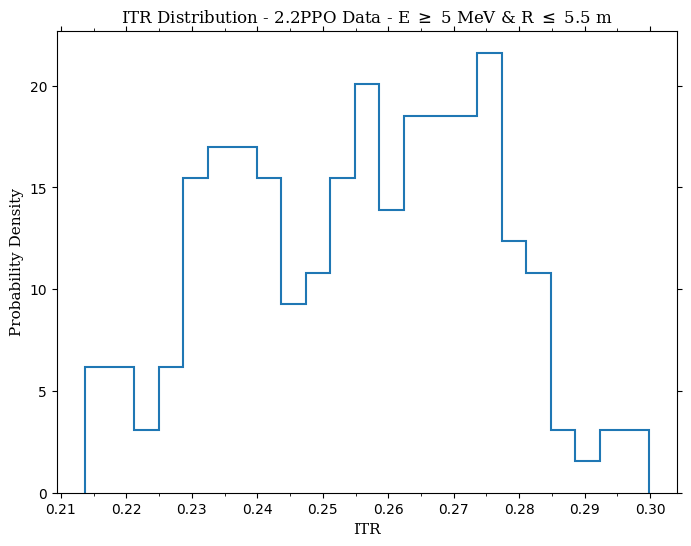

In [18]:
bins = 23

fig, ax = plt.subplots(figsize = (8, 6))

#sn.histplot(itr, bins = bins, element = 'step', alpha = 0, linewidth = 1.2, stat = 'density')
plt.hist(itr, bins = bins, histtype='step', linewidth=1.5, density = True)

plt.xlabel('ITR', fontdict = font_style_axis)
plt.ylabel('Probability Density', fontdict = font_style_axis)

# --- Markers ---
ax.xaxis.set_minor_locator(MultipleLocator(0.005))
ax.xaxis.set_major_locator(MultipleLocator(0.01))

#ax.yaxis.set_minor_locator(MultipleLocator(0.01))
#ax.yaxis.set_major_locator(MultipleLocator(0.05))

ax.tick_params(which='minor', top=True, bottom=True, left=True, right=True)
ax.tick_params(which='major', top=True, bottom=True, left=True, right=True)

#plt.xlim(0.22, 0.29)

plt.title(rf'ITR Distribution - 2.2PPO Data - E $\geq$ {en_inf_cut} MeV & R $\leq$ {posr_cut*10**(-3)} m', 
         fontdict = font_style_title)

#plt.savefig(save_path + f'ITR_E_{en_inf_cut}_MeV_R_{posr_cut}_mm.png', dpi=300, bbox_inches='tight')

plt.show()